# 02 — Deep Learning Paradigms

Deep learning is not a single learning strategy.

Different deep learning paradigms define different ways in which a neural network can learn from data. The learning paradigm determines what information is available during training, what objective the model optimizes, and how the learned representation is used.

In this notebook, we study the major deep learning paradigms:

- Supervised Deep Learning
- Unsupervised Deep Learning
- Self-Supervised Learning
- Semi-Supervised Deep Learning
- Deep Reinforcement Learning
- Generative Deep Learning
- Representation Learning
- Transfer Learning
- Multi-Task Learning

The goal is not only to implement these approaches, but to understand **what they learn, why they work, and when they are useful**.

## 1.1 What is a Deep Learning Paradigm?

A deep learning paradigm describes the way a neural network obtains its learning signal.

At a high level, the learning signal can come from:

1. **Human-provided labels**
2. **The structure of the data itself**
3. **Artificial labels created from the data**
4. **A mixture of labeled and unlabeled data**
5. **Rewards obtained through interaction with an environment**
6. **A generative objective**
7. **Knowledge transferred from another task or dataset**

Therefore, two neural networks can have similar architectures but belong to very different learning paradigms because their training objectives and sources of supervision are different.

## 1.2 General Deep Learning Formulation

A neural network can be represented as a parameterized function:

$$
\hat{y} = f_{\theta}(x)
$$

where:

- $x$ is the input
- $\hat{y}$ is the model output
- $\theta$ represents the learnable parameters

Training consists of finding parameters that optimize an objective:

$$
\theta^* = \arg\min_{\theta} \mathcal{L}(\theta)
$$

The important difference between learning paradigms is the definition of the objective $\mathcal{L}$ and the source of the learning signal.

For example:

- Supervised learning uses known target labels.
- Autoencoders learn to reconstruct their inputs.
- Self-supervised learning creates learning targets from the data itself.
- Reinforcement learning learns from rewards.
- Generative models learn to model the data distribution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.8.0+cu128
CUDA available: True
CUDA version: 12.8
Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [2]:
x = torch.randn(1000, 1000, device=device)
y = torch.randn(1000, 1000, device=device)

z = x @ y

print("Tensor device:", z.device)
print("Tensor shape:", z.shape)

Tensor device: cuda:0
Tensor shape: torch.Size([1000, 1000])


## 1.3 Taxonomy of Deep Learning Paradigms

We can organize deep learning paradigms according to the source of their learning signal.

| Paradigm | Learning Signal | Typical Objective |
|---|---|---|
| Supervised Learning | Human-provided labels | Prediction error |
| Unsupervised Learning | Data structure | Reconstruction / distribution modeling |
| Self-Supervised Learning | Targets generated from data | Representation learning |
| Semi-Supervised Learning | Labeled + unlabeled data | Supervised + unsupervised objectives |
| Deep Reinforcement Learning | Rewards from environment | Expected return |
| Generative Learning | Data distribution | Generate realistic samples |
| Transfer Learning | Knowledge from another task | Adapt pretrained representation |
| Multi-Task Learning | Multiple related tasks | Joint optimization |

These categories can overlap.

For example, a Variational Autoencoder is an unsupervised generative model, while a pretrained Transformer can be used for supervised, self-supervised, or transfer-learning workflows.

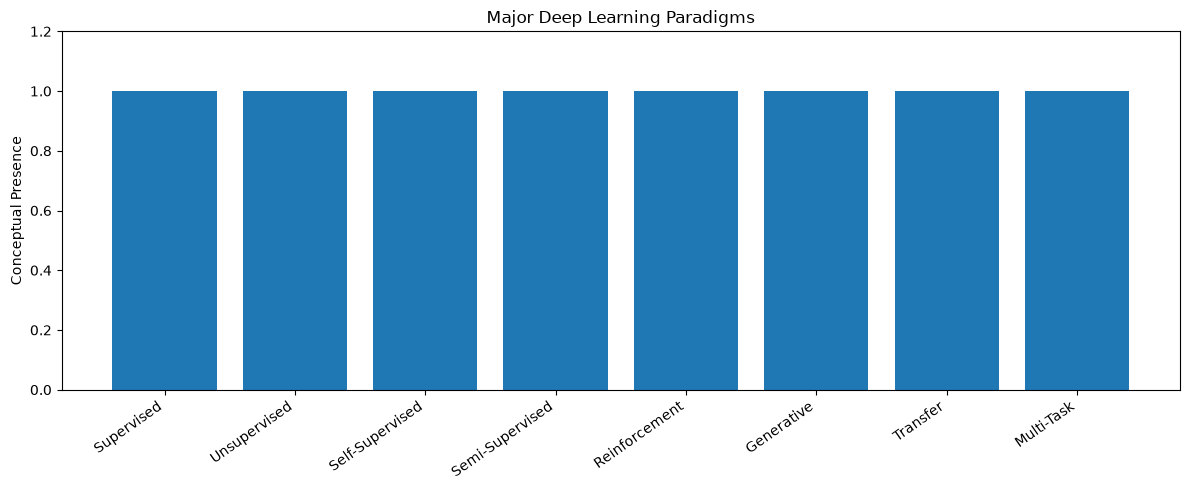

In [3]:
paradigms = [
    "Supervised",
    "Unsupervised",
    "Self-Supervised",
    "Semi-Supervised",
    "Reinforcement",
    "Generative",
    "Transfer",
    "Multi-Task"
]

positions = np.arange(len(paradigms))

plt.figure(figsize=(12, 5))
plt.bar(positions, np.ones(len(paradigms)))

plt.xticks(positions, paradigms, rotation=35, ha="right")
plt.ylabel("Conceptual Presence")
plt.title("Major Deep Learning Paradigms")
plt.ylim(0, 1.2)
plt.tight_layout()
plt.show()

## 1.4 Paradigm vs Architecture

A learning paradigm and a neural network architecture are not the same thing.

### Learning paradigm

Describes **how the model learns**.

Examples:

- supervised learning
- self-supervised learning
- reinforcement learning
- transfer learning

### Architecture

Describes **how the neural network is constructed**.

Examples:

- MLP
- CNN
- RNN
- LSTM
- GRU
- Transformer
- Autoencoder
- U-Net

The same architecture can be used under different paradigms.

For example, a Transformer can be trained using:

- supervised learning
- self-supervised learning
- semi-supervised learning
- transfer learning

Therefore:

$$
\boxed{\text{Learning Paradigm} \neq \text{Neural Network Architecture}}
$$

## 1.5 Notebook Roadmap

We will now study each paradigm progressively.

### Part A — Sources of Supervision

1. Supervised Deep Learning
2. Unsupervised Deep Learning
3. Self-Supervised Learning
4. Semi-Supervised Deep Learning

### Part B — Specialized Learning Paradigms

5. Deep Reinforcement Learning
6. Generative Deep Learning
7. Representation Learning

### Part C — Knowledge Reuse

8. Transfer Learning
9. Multi-Task Learning

Finally, we will compare the paradigms and build an end-to-end demonstration showing how the learning objective changes the behavior of a neural network.

The central question throughout this notebook is:

> **Where does the learning signal come from, and what does the neural network learn from it?**

## 2.1 Supervised Deep Learning

Supervised deep learning is a learning paradigm in which a neural network learns from a dataset containing input examples and corresponding target labels.

The model learns a mapping from an input $x$ to a target $y$:

$$
\hat{y} = f_{\theta}(x)
$$

where:

- $x$ is the input
- $y$ is the true target
- $\hat{y}$ is the model prediction
- $\theta$ represents the learnable parameters of the neural network

The objective of training is to make the prediction $\hat{y}$ as close as possible to the true target $y$.

This is achieved by defining a loss function:

$$
\mathcal{L}(y,\hat{y})
$$

and optimizing the neural network parameters:

$$
\theta^* = \arg\min_{\theta} \mathcal{L}(y,\hat{y})
$$

### Basic supervised learning process

1. Provide an input $x$.
2. The neural network performs a forward pass.
3. The network produces a prediction $\hat{y}$.
4. The prediction is compared with the true target $y$.
5. A loss value is calculated.
6. Backpropagation computes gradients.
7. An optimizer updates the parameters.
8. The process is repeated over many training examples and epochs.

The important idea is:

$$
\boxed{
\text{Input} \rightarrow
\text{Neural Network} \rightarrow
\text{Prediction} \rightarrow
\text{Loss} \rightarrow
\text{Backpropagation} \rightarrow
\text{Parameter Update}
}
$$

Supervised deep learning is commonly used for:

- Image classification
- Object detection
- Image segmentation
- Text classification
- Speech recognition
- Regression
- Time-series prediction
- Medical image analysis

                 Training Data
              ┌─────────────────┐
              │ Input x         │
              │ Target y        │
              └────────┬────────┘
                       │
                       ▼
              ┌─────────────────┐
              │ Neural Network  │
              │   fθ(x)         │
              └────────┬────────┘
                       │
                       ▼
                 Prediction ŷ
                       │
                       ▼
              ┌─────────────────┐
              │  Loss Function  │
              │ L(y, ŷ)         │
              └────────┬────────┘
                       │
                       ▼
               Backpropagation
                       │
                       ▼
              Parameter Update
                       │
                       └──────► Repeat

## 2.2 Supervised Deep Learning Tasks

Supervised deep learning mainly contains two fundamental prediction problems:

1. Classification
2. Regression

### Classification

Classification predicts a discrete class or category.

Examples:

- Cat vs Dog
- Spam vs Not Spam
- Disease vs Healthy
- Digit classification from 0 to 9

For a classification problem, the network typically produces class scores or probabilities.

For $K$ classes, the output can be represented as:

$$
\hat{\mathbf{y}} =
[\hat{y}_1,\hat{y}_2,\ldots,\hat{y}_K]
$$

A softmax function converts logits into class probabilities:

$$
P(y=k|x)
=
\frac{e^{z_k}}
{\sum_{j=1}^{K} e^{z_j}}
$$

The predicted class is:

$$
\hat{y} = \arg\max_k P(y=k|x)
$$

### Regression

Regression predicts a continuous numerical value.

Examples:

- House price prediction
- Temperature prediction
- Demand forecasting
- Age prediction
- Sensor-value prediction

For regression, the output is usually a continuous value:

$$
\hat{y} = f_{\theta}(x)
$$

A common regression loss is Mean Squared Error:

$$
\text{MSE}
=
\frac{1}{N}
\sum_{i=1}^{N}
(y_i-\hat{y}_i)^2
$$

### Comparison

| Task | Target | Example | Common Output |
|---|---|---|---|
| Binary Classification | Two classes | Spam detection | Probability/logit |
| Multiclass Classification | Multiple classes | Digit recognition | Class probabilities |
| Regression | Continuous value | House price | Real number |

The neural network architecture and loss function should match the task.

## 2.3 A Simple Supervised Learning Dataset

In [4]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_classification(
    n_samples=2000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    class_sep=1.5,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training samples:", X_train.shape)
print("Test samples:", X_test.shape)
print("Classes:", np.unique(y_train))

Training samples: (1600, 2)
Test samples: (400, 2)
Classes: [0 1]


## Visualization

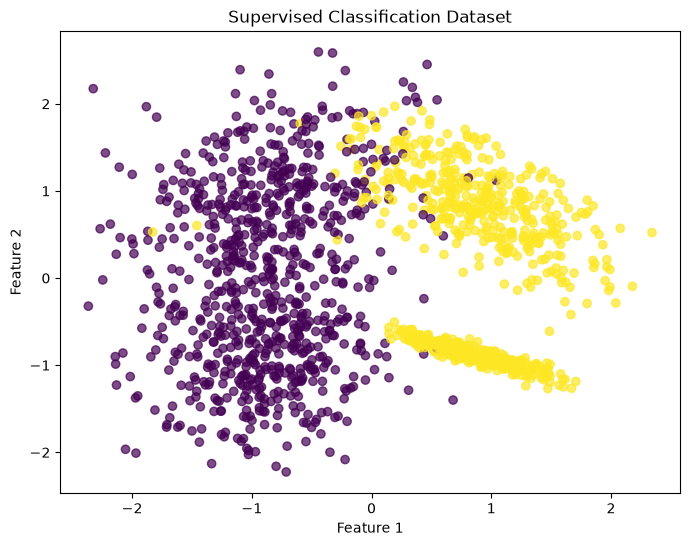

In [5]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    alpha=0.7
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Supervised Classification Dataset")
plt.show()

## 2.4 Converting Data to PyTorch Tensors

In [6]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32,
    device=device
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32,
    device=device
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long,
    device=device
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long,
    device=device
)

print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)
print("Device:", X_train_tensor.device)

X_train: torch.Size([1600, 2])
y_train: torch.Size([1600])
Device: cuda:0


## 2.5 Building a Supervised Neural Network

We now construct a small multilayer perceptron (MLP) for binary classification.

The network receives two input features and produces two output logits corresponding to the two classes.

Architecture:

$$
2
\rightarrow
16
\rightarrow
16
\rightarrow
2
$$

The hidden layers use the ReLU activation function.

The final layer produces logits rather than probabilities.

For multiclass classification, we can use:

$$
\text{CrossEntropyLoss}
$$

PyTorch's `CrossEntropyLoss` internally combines the appropriate log-softmax operation with negative log-likelihood loss, so an explicit softmax layer should not be added before it.

In [7]:
class ClassificationNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        return self.network(x)


model = ClassificationNetwork().to(device)

print(model)

ClassificationNetwork(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=2, bias=True)
  )
)


## 2.6 Loss Function and Optimizer

In [8]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)

Loss function: CrossEntropyLoss()
Optimizer: Adam


### Why Cross-Entropy Loss?

For classification, the model produces logits:

$$
\mathbf{z}
=
[z_1,z_2,\ldots,z_K]
$$

Cross-entropy measures how well these predictions correspond to the correct class.

For a single example:

$$
\mathcal{L}
=
-\log P(y|x)
$$

A correct and confident prediction produces a small loss.

A wrong and confident prediction produces a large loss.

### Why Adam?

Adam is an adaptive optimization algorithm that adjusts parameter updates using estimates of the first and second moments of the gradients.

The optimizer attempts to minimize the training loss by updating:

$$
\theta
\leftarrow
\theta-\eta\nabla_{\theta}\mathcal{L}
$$

where $\eta$ is the learning rate.

## 2.7 Training Loop

In [9]:
epochs = 100

train_losses = []
train_accuracies = []

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    logits = model(X_train_tensor)

    loss = criterion(
        logits,
        y_train_tensor
    )

    loss.backward()

    optimizer.step()

    predictions = torch.argmax(
        logits,
        dim=1
    )

    accuracy = (
        predictions == y_train_tensor
    ).float().mean().item()

    train_losses.append(loss.item())
    train_accuracies.append(accuracy)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1:3d}/{epochs} | "
            f"Loss: {loss.item():.4f} | "
            f"Accuracy: {accuracy:.4f}"
        )

Epoch  10/100 | Loss: 0.6577 | Accuracy: 0.8012
Epoch  20/100 | Loss: 0.6248 | Accuracy: 0.9500
Epoch  30/100 | Loss: 0.5881 | Accuracy: 0.9537
Epoch  40/100 | Loss: 0.5470 | Accuracy: 0.9556
Epoch  50/100 | Loss: 0.5012 | Accuracy: 0.9587
Epoch  60/100 | Loss: 0.4509 | Accuracy: 0.9594
Epoch  70/100 | Loss: 0.3982 | Accuracy: 0.9631
Epoch  80/100 | Loss: 0.3462 | Accuracy: 0.9650
Epoch  90/100 | Loss: 0.2981 | Accuracy: 0.9656
Epoch 100/100 | Loss: 0.2565 | Accuracy: 0.9644


## 2.8 Training Curves

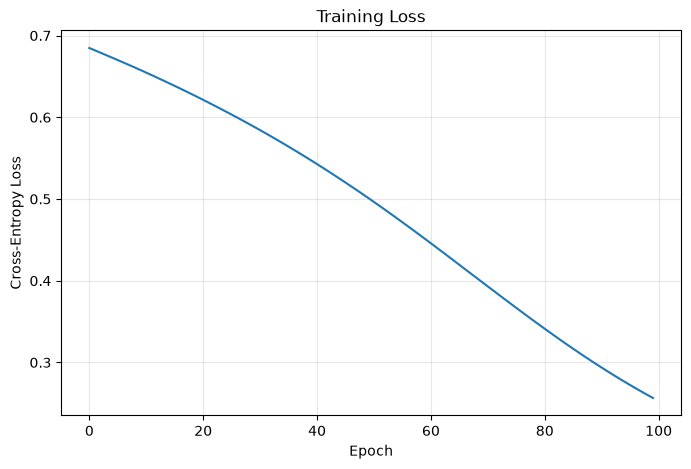

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Loss")

plt.grid(alpha=0.3)
plt.show()

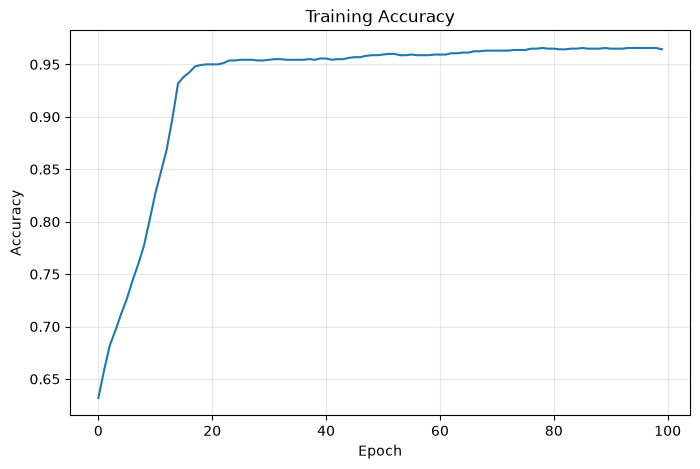

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")

plt.grid(alpha=0.3)
plt.show()

## 2.9 Evaluation

In [12]:
model.eval()

with torch.no_grad():

    test_logits = model(X_test_tensor)

    test_predictions = torch.argmax(
        test_logits,
        dim=1
    )

    test_accuracy = (
        test_predictions == y_test_tensor
    ).float().mean().item()

print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9750


## 2.9 Evaluation

During evaluation:

- The model is switched to evaluation mode using `model.eval()`.
- Gradient computation is disabled using `torch.no_grad()`.
- Predictions are generated for unseen test data.
- Accuracy is calculated by comparing predictions with the true labels.

The test set estimates how well the learned model generalizes to previously unseen examples.

A high training accuracy alone does not guarantee good generalization.

## 2.10 Decision Boundary

In [13]:
model.eval()

x_min, x_max = X_test[:, 0].min() - 1, X_test[:, 0].max() + 1
y_min, y_max = X_test[:, 1].min() - 1, X_test[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[
    xx.ravel(),
    yy.ravel()
]

grid_tensor = torch.tensor(
    grid,
    dtype=torch.float32,
    device=device
)

with torch.no_grad():
    grid_logits = model(grid_tensor)
    grid_predictions = torch.argmax(
        grid_logits,
        dim=1
    )

grid_predictions = grid_predictions.cpu().numpy()

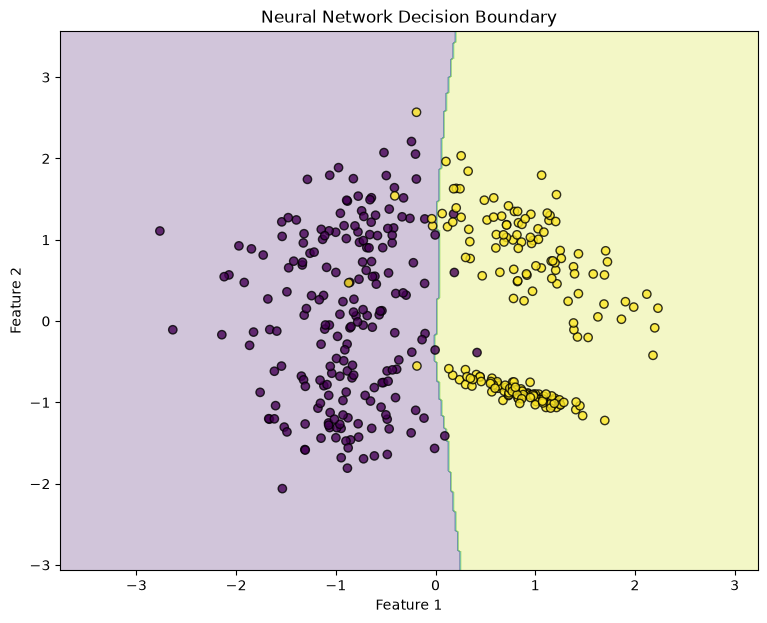

In [14]:
plt.figure(figsize=(9, 7))

plt.contourf(
    xx,
    yy,
    grid_predictions.reshape(xx.shape),
    alpha=0.25
)

plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    edgecolors="black",
    alpha=0.8
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Neural Network Decision Boundary")

plt.show()

This is a particularly useful visualization because it shows what the neural network actually learned rather than only reporting an accuracy number.

## 2.11 Complete Supervised Learning Pipeline

The complete supervised deep learning workflow can be summarized as:

$$
\boxed{
\text{Dataset}
\rightarrow
\text{Preprocessing}
\rightarrow
\text{Train/Test Split}
\rightarrow
\text{Neural Network}
\rightarrow
\text{Forward Pass}
\rightarrow
\text{Loss}
\rightarrow
\text{Backpropagation}
\rightarrow
\text{Optimizer}
\rightarrow
\text{Evaluation}
}
$$

The central learning loop is:

$$
x
\rightarrow
f_{\theta}(x)
\rightarrow
\hat{y}
\rightarrow
\mathcal{L}(y,\hat{y})
\rightarrow
\nabla_{\theta}\mathcal{L}
\rightarrow
\theta_{\text{new}}
$$

This process repeats many times until the model learns parameters that provide useful predictions.

### Key idea

Supervised learning requires an explicit target signal.

The neural network learns by minimizing the difference between its predictions and the provided targets.

$$
\boxed{
\text{Supervised Learning}
=
\text{Input}
+
\text{Known Target}
+
\text{Prediction Error}
}
$$

## 2.12 Unsupervised Deep Learning

Unsupervised deep learning learns useful patterns or representations from data **without requiring human-provided target labels**.

Instead of learning:

$$
x \rightarrow y
$$

the model attempts to discover structure within the input data.

Common objectives include:

- Reconstruction
- Representation learning
- Density estimation
- Generative modeling
- Discovering latent structure

One important family of unsupervised deep learning models is the **autoencoder**.

An autoencoder learns to represent an input in a lower-dimensional latent space and then reconstruct the original input.

The basic structure is:

$$
x
\rightarrow
\text{Encoder}
\rightarrow
z
\rightarrow
\text{Decoder}
\rightarrow
\hat{x}
$$

where:

- $x$ is the original input
- $z$ is the learned latent representation
- $\hat{x}$ is the reconstructed input

The training objective is to make:

$$
\hat{x} \approx x
$$

Therefore, the model can learn without an externally provided class label.

## 2.13 Autoencoders

An autoencoder consists of two main components:

### Encoder

The encoder maps the input into a latent representation:

$$
z = f_{\theta}(x)
$$

The latent representation $z$ is usually smaller than the original input.

### Decoder

The decoder reconstructs the input:

$$
\hat{x} = g_{\phi}(z)
$$

Combining both:

$$
\hat{x}
=
g_{\phi}(f_{\theta}(x))
$$

The model is trained by minimizing a reconstruction loss:

$$
\mathcal{L}_{reconstruction}
=
\mathcal{L}(x,\hat{x})
$$

For numerical data, Mean Squared Error is commonly used:

$$
\mathcal{L}_{MSE}
=
\frac{1}{N}
\sum_{i=1}^{N}
(x_i-\hat{x}_i)^2
$$

The encoder therefore learns a compact representation that preserves information necessary for reconstruction.

### Architecture

$$
\boxed{
\text{Input}
\rightarrow
\text{Encoder}
\rightarrow
\text{Latent Space}
\rightarrow
\text{Decoder}
\rightarrow
\text{Reconstruction}
}
$$

## 2.14 Creating Data for the Autoencoder

In [15]:
from sklearn.datasets import make_blobs

X_unsupervised, _ = make_blobs(
    n_samples=2000,
    centers=3,
    n_features=4,
    cluster_std=1.2,
    random_state=42
)

scaler_ae = StandardScaler()

X_unsupervised = scaler_ae.fit_transform(
    X_unsupervised
)

X_ae = torch.tensor(
    X_unsupervised,
    dtype=torch.float32,
    device=device
)

print("Dataset shape:", X_ae.shape)
print("Tensor device:", X_ae.device)

Dataset shape: torch.Size([2000, 4])
Tensor device: cuda:0


## 2.15 Building an Autoencoder

We will use a small fully connected autoencoder.

The architecture is:

$$
4
\rightarrow
16
\rightarrow
8
\rightarrow
2
\rightarrow
8
\rightarrow
16
\rightarrow
4
$$

The two-dimensional latent space allows us to visualize the learned representation.

In [16]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 2)
        )

        self.decoder = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 4)
        )

    def forward(self, x):
        z = self.encoder(x)
        reconstruction = self.decoder(z)

        return reconstruction


autoencoder = Autoencoder().to(device)

print(autoencoder)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=4, bias=True)
  )
)
